In [1]:
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

In [4]:
temp = xr.open_dataset('temp_data.nc') 
precip = xr.open_dataset('Precip_data.nc')
RH = xr.open_dataset('RH_data.nc')
WS = xr.open_dataset('wind_speed_data.nc')

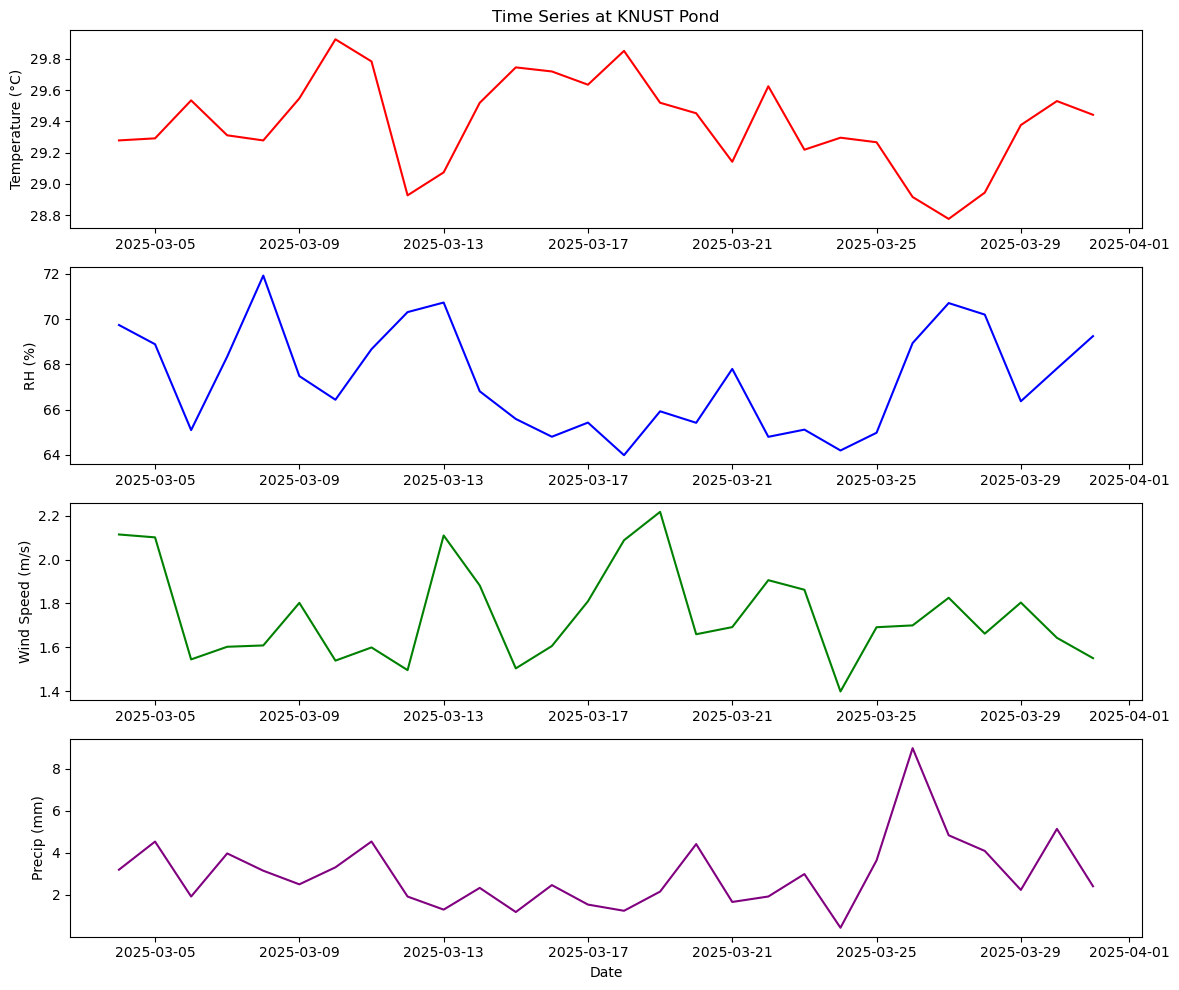

In [11]:
import xarray as xr
import matplotlib.pyplot as plt

# Load datasets
temp = xr.open_dataset('temp_data.nc')
RH = xr.open_dataset('RH_data.nc')
WS = xr.open_dataset('wind_speed_data.nc')
precip = xr.open_dataset('Precip_data.nc')

# Target location: KNUST Pond
lat_pt = 6.6657
lon_pt = -1.57304

# Interpolate to exact point
temp_series = temp['T2M'].interp(lat=lat_pt, lon=lon_pt)
rh_series = RH['RH2M'].interp(lat=lat_pt, lon=lon_pt)
ws_series = WS['WS2M'].interp(lat=lat_pt, lon=lon_pt)
precip_series = precip['PRECTOTCORR'].interp(lat=lat_pt, lon=lon_pt)

# Create multipanel plot
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(12, 10), sharex=False)

# Plot each variable
axs[0].plot(temp_series['time'], temp_series, color='red')
axs[0].set_ylabel('Temperature (°C)')
axs[0].set_title('Time Series at KNUST Pond')

axs[1].plot(rh_series['time'], rh_series, color='blue')
axs[1].set_ylabel('RH (%)')

axs[2].plot(ws_series['time'], ws_series, color='green')
axs[2].set_ylabel('Wind Speed (m/s)')

axs[3].plot(precip_series['time'], precip_series, color='purple')
axs[3].set_ylabel('Precip (mm)')
axs[3].set_xlabel('Date')

plt.tight_layout()
plt.show()


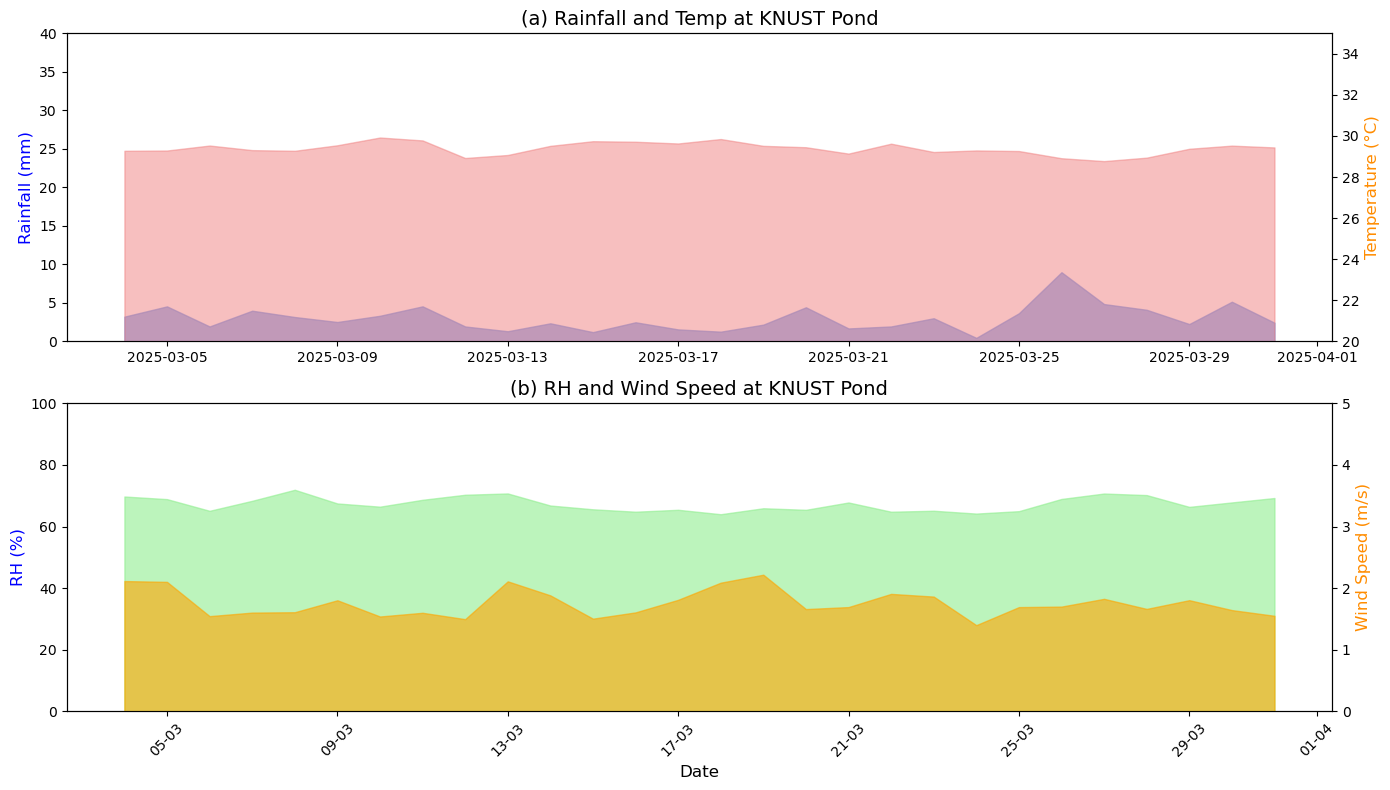

In [15]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load datasets
temp = xr.open_dataset('temp_data.nc')
RH = xr.open_dataset('RH_data.nc')
WS = xr.open_dataset('wind_speed_data.nc')
precip = xr.open_dataset('Precip_data.nc')

# Coordinates for KNUST Pond
lat_pt = 6.6657
lon_pt = -1.57304

# Interpolate to location
temp_series = temp['T2M'].interp(lat=lat_pt, lon=lon_pt)
rh_series = RH['RH2M'].interp(lat=lat_pt, lon=lon_pt)
ws_series = WS['WS2M'].interp(lat=lat_pt, lon=lon_pt)
precip_series = precip['PRECTOTCORR'].interp(lat=lat_pt, lon=lon_pt)

# Create figure
fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# ------------------ Panel A: Rainfall & Temp ------------------
ax1 = axs[0]
ax2 = ax1.twinx()

ax1.fill_between(precip_series['time'], precip_series, color='cornflowerblue', alpha=0.7, label='Rainfall')
ax2.fill_between(temp_series['time'], temp_series, color='lightcoral', alpha=0.5, label='Temperature')

ax1.set_ylabel('Rainfall (mm)', color='blue', fontsize=12)
ax2.set_ylabel('Temperature (°C)', color='darkorange', fontsize=12)

ax1.set_ylim(0, 40)
ax2.set_ylim(20, 35)

ax1.set_title('(a) Rainfall and Temp at KNUST Pond', fontsize=14)

# ------------------ Panel B: RH & Wind Speed ------------------
ax3 = axs[1]
ax4 = ax3.twinx()

ax3.fill_between(rh_series['time'], rh_series, color='lightgreen', alpha=0.6, label='RH')
ax4.fill_between(ws_series['time'], ws_series, color='orange', alpha=0.6, label='Wind Speed')

ax3.set_ylabel('RH (%)', color='blue', fontsize=12)
ax4.set_ylabel('Wind Speed (m/s)', color='darkorange', fontsize=12)

ax3.set_ylim(0, 100)
ax4.set_ylim(0, 5)

ax3.set_title('(b) RH and Wind Speed at KNUST Pond', fontsize=14)

# X-axis formatting
axs[1].set_xlabel('Date', fontsize=12)
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
axs[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


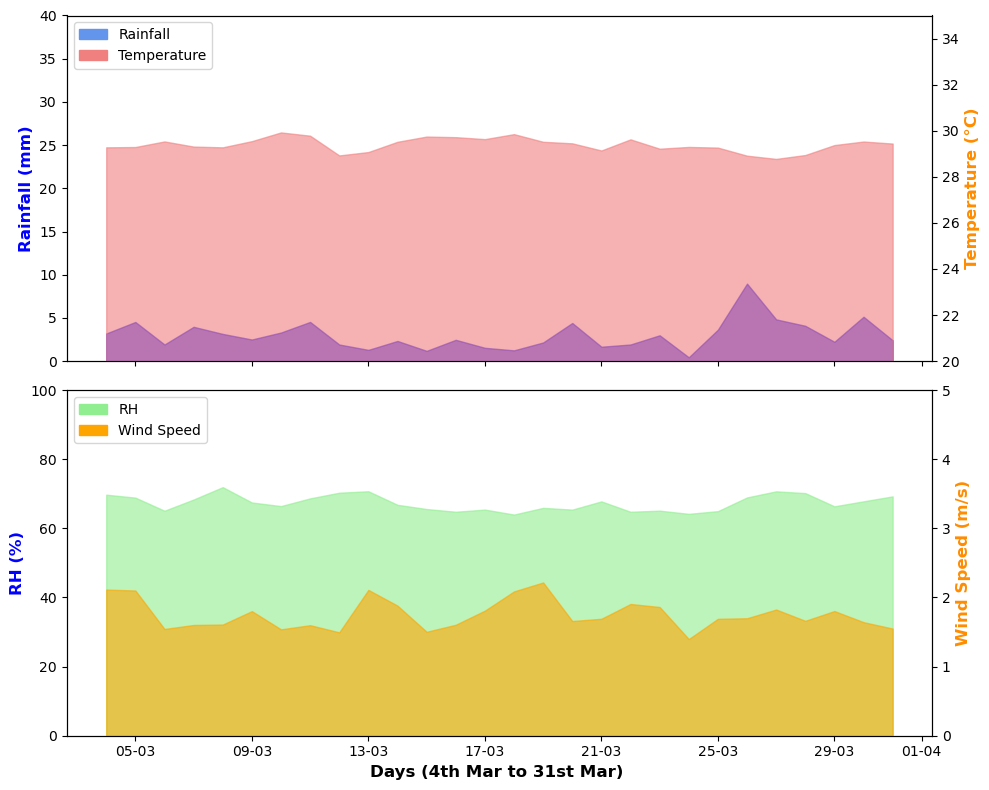

In [26]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

# Load datasets
temp = xr.open_dataset('temp_data.nc')
RH = xr.open_dataset('RH_data.nc')
WS = xr.open_dataset('wind_speed_data.nc')
precip = xr.open_dataset('Precip_data.nc')

# Coordinates for KNUST Pond
lat_pt = 6.6657
lon_pt = -1.57304

# Interpolate to location
temp_series = temp['T2M'].interp(lat=lat_pt, lon=lon_pt)
rh_series = RH['RH2M'].interp(lat=lat_pt, lon=lon_pt)
ws_series = WS['WS2M'].interp(lat=lat_pt, lon=lon_pt)
precip_series = precip['PRECTOTCORR'].interp(lat=lat_pt, lon=lon_pt)

# Create figure
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# ------------------ Panel A: Rainfall & Temp ------------------
ax1 = axs[0]
ax2 = ax1.twinx()

ax1.fill_between(precip_series['time'], precip_series, color='blue', alpha=0.6)
ax2.fill_between(temp_series['time'], temp_series, color='lightcoral', alpha=0.6)

ax1.set_ylabel('Rainfall (mm)', color='blue', fontweight= 'bold', fontsize=12)
ax2.set_ylabel('Temperature (°C)', color='darkorange', fontweight= 'bold', fontsize=12)

ax1.set_ylim(0, 40)
ax2.set_ylim(20, 35)

# Legend for Panel A
rain_patch = mpatches.Patch(color='cornflowerblue', label='Rainfall')
temp_patch = mpatches.Patch(color='lightcoral', label='Temperature')
ax1.legend(handles=[rain_patch, temp_patch], loc='upper left')

# ------------------ Panel B: RH & Wind Speed ------------------
ax3 = axs[1]
ax4 = ax3.twinx()

ax3.fill_between(rh_series['time'], rh_series, color='lightgreen', alpha=0.6)
ax4.fill_between(ws_series['time'], ws_series, color='orange', alpha=0.6)

ax3.set_ylabel('RH (%)', color='blue', fontweight= 'bold', fontsize=12)
ax4.set_ylabel('Wind Speed (m/s)', color='darkorange', fontweight= 'bold', fontsize=12)

ax3.set_ylim(0, 100)
ax4.set_ylim(0, 5)

# Legend for Panel B
rh_patch = mpatches.Patch(color='lightgreen', label='RH')
ws_patch = mpatches.Patch(color='orange', label='Wind Speed')
ax3.legend(handles=[rh_patch, ws_patch], loc='upper left')

# X-axis formatting
axs[1].set_xlabel('Days (4th Mar to 31st Mar) ', fontweight= 'bold', fontsize=12)
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
axs[1].tick_params(axis='x')

plt.tight_layout()
plt.show()


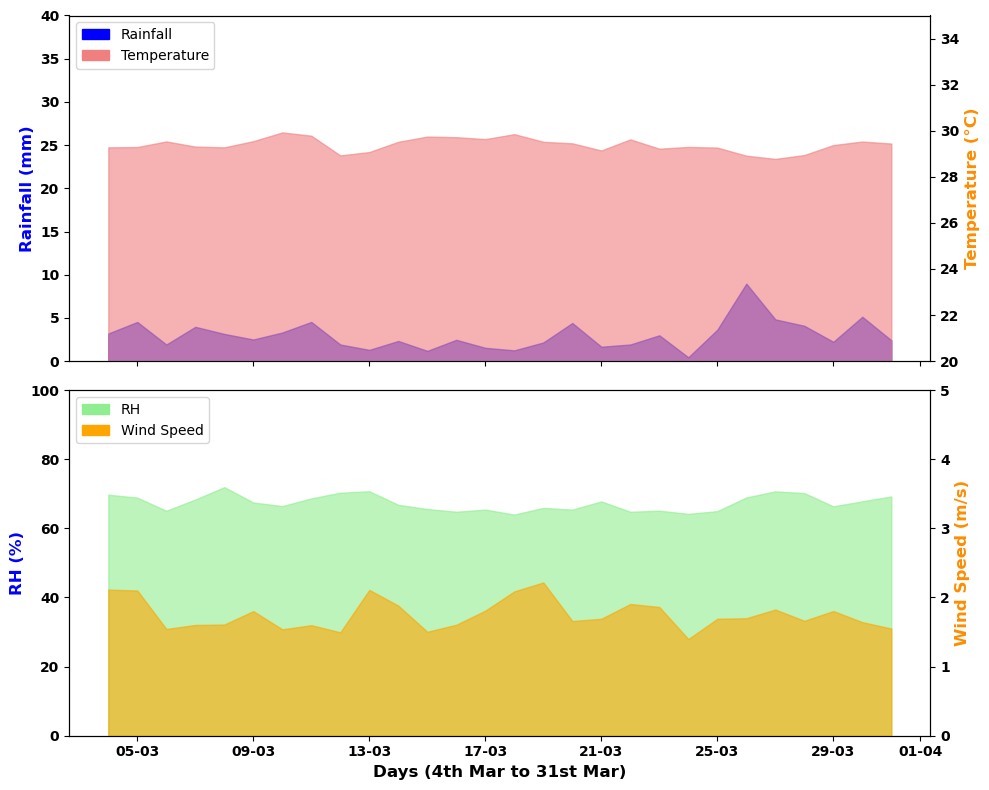

In [33]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

# Load datasets
temp = xr.open_dataset('temp_data.nc')
RH = xr.open_dataset('RH_data.nc')
WS = xr.open_dataset('wind_speed_data.nc')
precip = xr.open_dataset('Precip_data.nc')

# Coordinates for KNUST Pond
lat_pt = 6.6657
lon_pt = -1.57304

# Interpolate to location
temp_series = temp['T2M'].interp(lat=lat_pt, lon=lon_pt)
rh_series = RH['RH2M'].interp(lat=lat_pt, lon=lon_pt)
ws_series = WS['WS2M'].interp(lat=lat_pt, lon=lon_pt)
precip_series = precip['PRECTOTCORR'].interp(lat=lat_pt, lon=lon_pt)

# Create figure
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# ------------------ Panel A: Rainfall & Temp ------------------
ax1 = axs[0]
ax2 = ax1.twinx()

ax1.fill_between(precip_series['time'], precip_series, color='blue', alpha=0.6)
ax2.fill_between(temp_series['time'], temp_series, color='lightcoral', alpha=0.6)

ax1.set_ylabel('Rainfall (mm)', color='blue', fontweight='bold', fontsize=12)
ax2.set_ylabel('Temperature (°C)', color='darkorange', fontweight='bold', fontsize=12)

ax1.set_ylim(0, 40)
ax2.set_ylim(20, 35)

# Legend for Panel A
rain_patch = mpatches.Patch(color='blue', label='Rainfall')
temp_patch = mpatches.Patch(color='lightcoral', label='Temperature')
ax1.legend(handles=[rain_patch, temp_patch], loc='upper left')

# ------------------ Panel B: RH & Wind Speed ------------------
ax3 = axs[1]
ax4 = ax3.twinx()

ax3.fill_between(rh_series['time'], rh_series, color='lightgreen', alpha=0.6)
ax4.fill_between(ws_series['time'], ws_series, color='orange', alpha=0.6)

ax3.set_ylabel('RH (%)', color='blue', fontweight='bold', fontsize=12)
ax4.set_ylabel('Wind Speed (m/s)', color='darkorange', fontweight='bold', fontsize=12)

ax3.set_ylim(0, 100)
ax4.set_ylim(0, 5)

# Legend for Panel B
rh_patch = mpatches.Patch(color='lightgreen', label='RH')
ws_patch = mpatches.Patch(color='orange', label='Wind Speed')
ax3.legend(handles=[rh_patch, ws_patch], loc='upper left')

# X-axis formatting
axs[1].set_xlabel('Days (4th Mar to 31st Mar)', fontweight='bold', fontsize=12)
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
axs[1].tick_params(axis='x')

# -------- BOLD TICK LABELS FOR ALL AXES --------
for ax in [ax1, ax2, ax3, ax4, axs[1]]:
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontsize(10)  # Adjust as needed

plt.tight_layout()
fig.savefig('panel.png',bbox_inches='tight',dpi=500)
plt.show()
